<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

In [ ]:
%pip install numpy matplotlib torch torchvision --quiet

## Aula 07b: CNN com Dataset Sintético de Dígitos

Nos notebooks anteriores trabalhamos com dois extremos:

- **Notebook 1:** padrões O e X criados à mão como matrizes 6×6
- **Notebook 2:** MNIST e CIFAR-10, datasets reais prontos para uso

Neste notebook vamos **criar o nosso próprio dataset de dígitos** (0–9) programaticamente, com ruído e variações. O objetivo é mostrar que:

1. Um dataset nada mais é do que uma coleção de imagens + rótulos
2. Podemos gerá-lo sinteticamente quando não temos dados reais
3. A mesma CNN do Notebook 2 aprende a classificar nossos dígitos

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Como gerar imagens de dígitos com código |
| **2** | Visualização e análise do dataset |
| **3** | Modelo CNN (mesma arquitetura do MNIST) |
| **4** | Treinamento |
| **5** | Avaliação e predição |

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

# cuda -> gpu nvidia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cpu


## 1. Gerando o Dataset de Dígitos

A ideia é simples: usamos o matplotlib para **renderizar cada dígito como uma imagem 28×28**. Para cada imagem adicionamos:

- **Ruído gaussiano**: simula imperfeições e evita overfitting
- **Deslocamento aleatório**: o dígito aparece em posições ligeiramente diferentes
- **Variação de tamanho**: fontes ligeiramente maiores ou menores

Isso cria diversidade artificial — o mesmo princípio do *data augmentation* do Notebook 2, mas aplicado na geração.

### Por que não usar o MNIST direto?

Poderíamos. Mas criar o dataset do zero mostra que:

- Qualquer imagem é apenas uma **matriz de números**
- Um dataset é apenas um **conjunto dessas matrizes + rótulos**
- O modelo não sabe se os dados são reais ou sintéticos — ele aprende padrões

In [8]:
def renderizar_digito(digito, tamanho=28, ruido=0.15, seed=None):
    """Gera uma imagem 28x28 de um dígito com ruído e posição variável."""
    rng = np.random.default_rng(seed)

    fig = Figure(figsize=(1, 1), dpi=tamanho)
    canvas = FigureCanvasAgg(fig)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')

    # Variação de posição e tamanho
    dx       = rng.uniform(-0.08, 0.08)
    dy       = rng.uniform(-0.08, 0.08)
    fontsize = rng.integers(16, 22)

    ax.text(0.5 + dx, 0.5 + dy, str(digito),
            ha='center', va='center',
            fontsize=fontsize, color='white', fontweight='bold')

    canvas.draw()
    buf  = canvas.buffer_rgba()
    img  = np.frombuffer(buf, dtype=np.uint8).reshape(tamanho, tamanho, 4)
    gray = img[:, :, 0].astype(float) / 255.0  # canal R = escala de cinza

    # Ruído gaussiano
    gray = np.clip(gray + rng.normal(0, ruido, gray.shape), 0, 1)

    return gray


def gerar_dataset(n_por_classe=300, tamanho=28, ruido=0.10, seed=42):
    """Gera n_por_classe imagens para cada dígito 0-9."""
    X, y = [], []
    for digito in range(10):
        for i in range(n_por_classe):
            img = renderizar_digito(digito, tamanho=tamanho, ruido=ruido,
                                    seed=seed * 1000 + digito * 100 + i)
            X.append(img)
            y.append(digito)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


print('Funções renderizar_digito e gerar_dataset definidas.')

Funções renderizar_digito e gerar_dataset definidas.


Gerando dataset de treino (3 000 imagens)...
Gerando dataset de teste  (1 000 imagens)...

Treino : (3000, 28, 28)  |  Teste: (1000, 28, 28)
Rótulos únicos: [0 1 2 3 4 5 6 7 8 9]


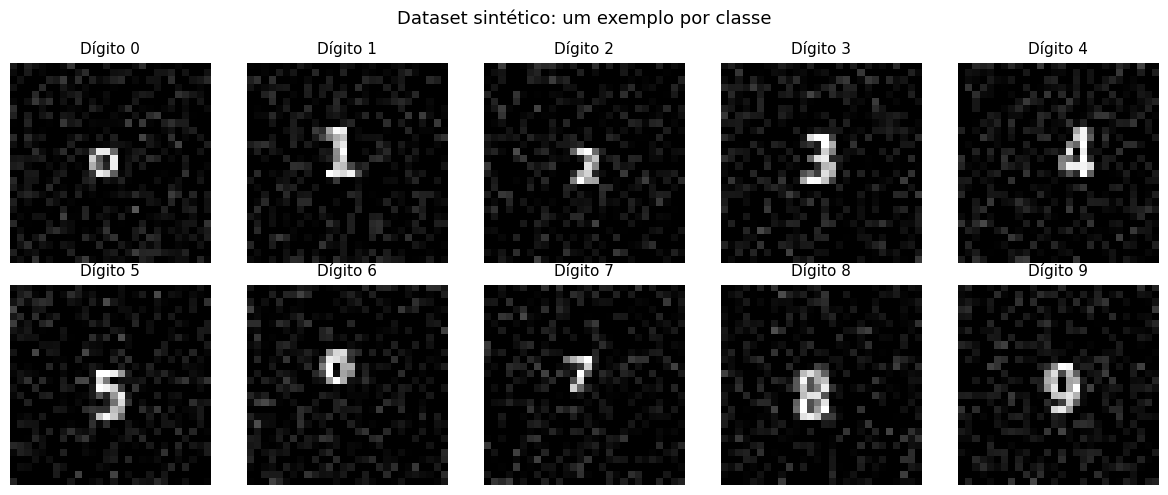

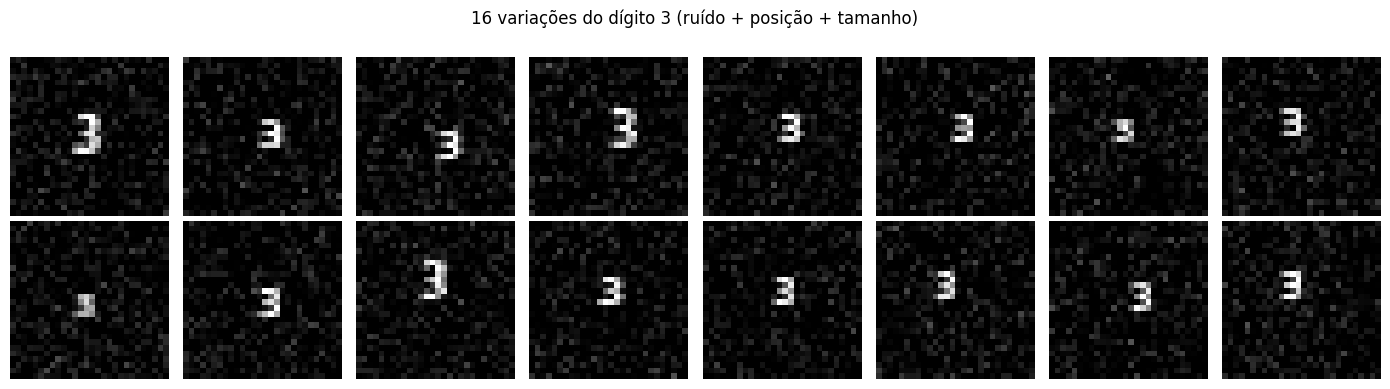

In [9]:
print('Gerando dataset de treino (3 000 imagens)...')
X_train, y_train = gerar_dataset(n_por_classe=300, seed=42)

print('Gerando dataset de teste  (1 000 imagens)...')
X_test, y_test = gerar_dataset(n_por_classe=100, seed=99)

print(f'\nTreino : {X_train.shape}  |  Teste: {X_test.shape}')
print(f'Rótulos únicos: {np.unique(y_train)}')

# Visualizar um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digito, ax in enumerate(axes.flat):
    idx = np.where(y_train == digito)[0][0]
    ax.imshow(X_train[idx], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Dígito {digito}', fontsize=11)
    ax.axis('off')
plt.suptitle('Dataset sintético: um exemplo por classe', fontsize=13)
plt.tight_layout()
plt.show()

# Mostrar variações do mesmo dígito
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for k, ax in enumerate(axes.flat):
    idx = np.where(y_train == 3)[0][k]
    ax.imshow(X_train[idx], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('16 variações do dígito 3 (ruído + posição + tamanho)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Modelo CNN

Usamos a mesma arquitetura do MNIST (Notebook 2): dois blocos convolucionais seguidos de uma cabeça classificadora.

A entrada tem shape `(batch, 1, 28, 28)` — mesma dimensão do MNIST, porque geramos imagens 28×28 em escala de cinza.

| Camada | Saída |
|--------|-------|
| Conv2d(1→32, 3×3) + ReLU | 32×26×26 |
| MaxPool2d(2) | 32×13×13 |
| Conv2d(32→64, 3×3) + ReLU | 64×11×11 |
| MaxPool2d(2) | 64×5×5 |
| Flatten + Linear(1600→128) + ReLU | 128 |
| Linear(128→10) | 10 logits |

In [10]:
class CNN_Digitos(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),  # (B, 32, 26, 26)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # (B, 32, 13, 13)
            nn.Conv2d(32, 64, kernel_size=3), # (B, 64, 11, 11)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # (B, 64, 5, 5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


modelo = CNN_Digitos().to(device)
total  = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total:,}')
print(modelo)

Parâmetros treináveis: 225,034
CNN_Digitos(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Treinamento

Antes de treinar, precisamos converter os arrays NumPy em tensores PyTorch e criar DataLoaders.

O shape esperado pelo `Conv2d` é `(batch, canais, altura, largura)`. Nossos dados são `(N, 28, 28)` — precisamos adicionar a dimensão de canal: `(N, 1, 28, 28)`.

In [11]:
# Converter para tensores e adicionar canal: (N, 28, 28) -> (N, 1, 28, 28)
X_tr = torch.tensor(X_train).unsqueeze(1)  # (3000, 1, 28, 28)
y_tr = torch.tensor(y_train)
X_te = torch.tensor(X_test).unsqueeze(1)   # (1000, 1, 28, 28)
y_te = torch.tensor(y_test)

loader_tr = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
loader_te = DataLoader(TensorDataset(X_te, y_te), batch_size=128, shuffle=False)

print(f'Shape de um batch: {next(iter(loader_tr))[0].shape}')

# Treinamento
criterio   = nn.CrossEntropyLoss() # Combina softmax + log + NLLLoss
otimizador = optim.Adam(modelo.parameters(), lr=1e-3)
EPOCHS     = 20
historico  = []

for ep in range(1, EPOCHS + 1):
    modelo.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for xb, yb in loader_tr:
        xb, yb = xb.to(device), yb.to(device)
        logits = modelo(xb)
        loss   = criterio(logits, yb)
        otimizador.zero_grad()
        loss.backward()
        otimizador.step()
        loss_soma += loss.item()
        acertos   += (logits.argmax(1) == yb).sum().item()
        total     += len(yb)

    modelo.eval()
    ac_te, tot_te = 0, 0
    with torch.no_grad():
        for xb, yb in loader_te:
            xb, yb = xb.to(device), yb.to(device)
            ac_te  += (modelo(xb).argmax(1) == yb).sum().item()
            tot_te += len(yb)

    historico.append((loss_soma / len(loader_tr), acertos / total, ac_te / tot_te))
    if ep % 5 == 0:
        print(f'Época {ep:2d} | Loss: {historico[-1][0]:.4f} | '
              f'Acc treino: {acertos/total:.3f} | Acc teste: {ac_te/tot_te:.3f}')

print('\nTreinamento concluído.')

Shape de um batch: torch.Size([64, 1, 28, 28])
Época  5 | Loss: 1.0949 | Acc treino: 0.591 | Acc teste: 0.700
Época 10 | Loss: 0.5483 | Acc treino: 0.822 | Acc teste: 0.860
Época 15 | Loss: 0.2985 | Acc treino: 0.907 | Acc teste: 0.931
Época 20 | Loss: 0.2048 | Acc treino: 0.937 | Acc teste: 0.938

Treinamento concluído.


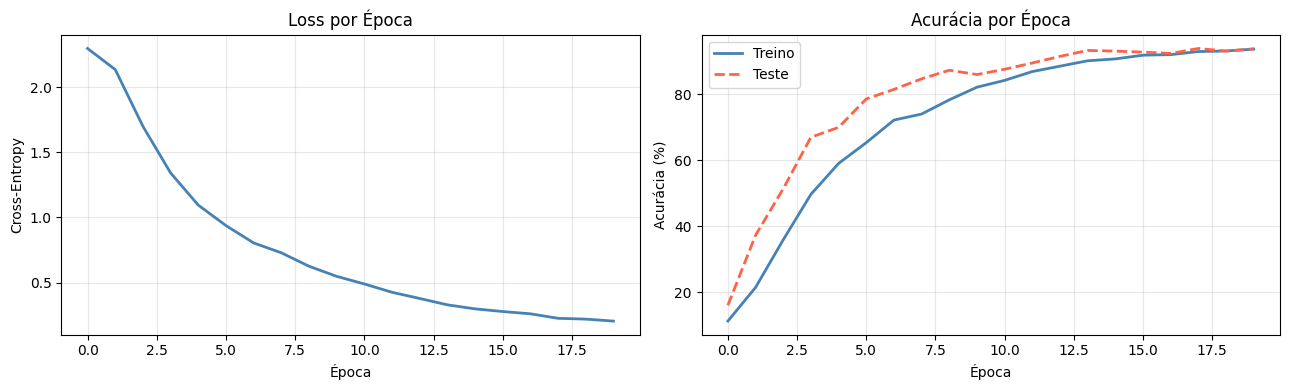

Acurácia final no teste: 93.8%


In [12]:
losses, accs_tr, accs_te = zip(*historico)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(losses, color='steelblue', lw=2)
axes[0].set_title('Loss por Época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in accs_tr], label='Treino', color='steelblue', lw=2)
axes[1].plot([a*100 for a in accs_te], label='Teste',  color='tomato', lw=2, linestyle='--')
axes[1].set_title('Acurácia por Época')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Acurácia final no teste: {accs_te[-1]*100:.1f}%')

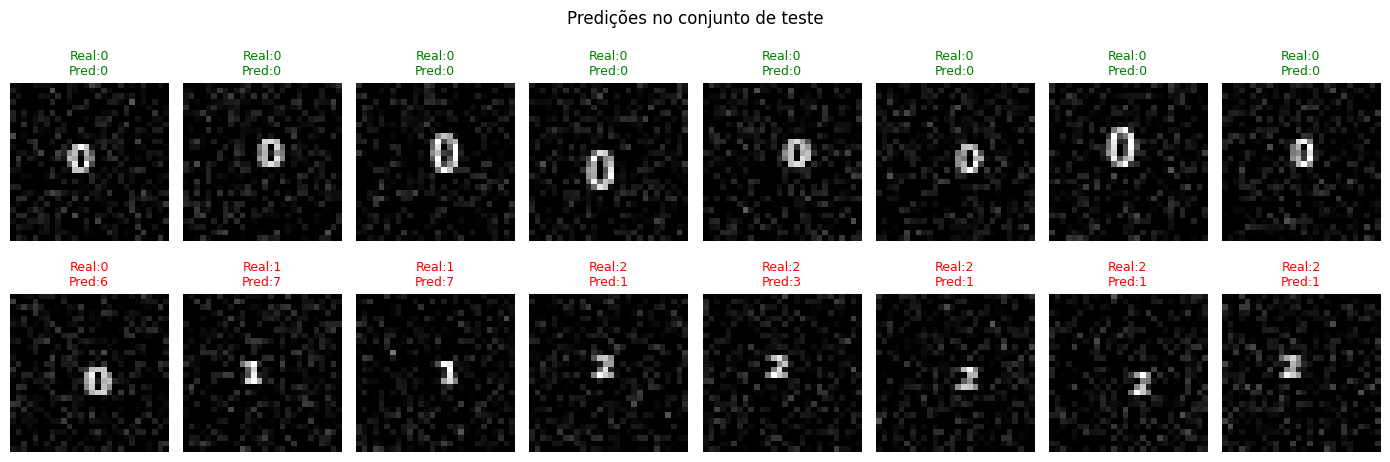

Acurácia por dígito:
  Dígito 0: 99.0%
  Dígito 1: 98.0%
  Dígito 2: 90.0%
  Dígito 3: 99.0%
  Dígito 4: 98.0%
  Dígito 5: 89.0%
  Dígito 6: 79.0%
  Dígito 7: 99.0%
  Dígito 8: 93.0%
  Dígito 9: 94.0%


In [13]:
# Predições no conjunto de teste
modelo.eval()
with torch.no_grad():
    logits = modelo(X_te.to(device))
    preds  = logits.argmax(1).cpu().numpy()

# Exemplos corretos e errados
corretos  = np.where(preds == y_test)[0]
erros     = np.where(preds != y_test)[0]

fig, axes = plt.subplots(2, 8, figsize=(14, 5))
for k, ax in enumerate(axes[0]):
    idx = corretos[k]
    ax.imshow(X_test[idx], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Real:{y_test[idx]}\nPred:{preds[idx]}', color='green', fontsize=9)
    ax.axis('off')

for k, ax in enumerate(axes[1]):
    if k < len(erros):
        idx = erros[k]
        ax.imshow(X_test[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Real:{y_test[idx]}\nPred:{preds[idx]}', color='red', fontsize=9)
    ax.axis('off')

axes[0, 0].set_ylabel('Corretas', fontsize=10, fontweight='bold', color='green')
axes[1, 0].set_ylabel('Erradas',  fontsize=10, fontweight='bold', color='red')
plt.suptitle('Predições no conjunto de teste', fontsize=12)
plt.tight_layout()
plt.show()

# Acurácia por dígito
print('Acurácia por dígito:')
for d in range(10):
    mask = y_test == d
    ac   = (preds[mask] == y_test[mask]).mean() * 100
    print(f'  Dígito {d}: {ac:.1f}%')

In [ ]:
import os
os.makedirs('models', exist_ok=True)
torch.save({'model_state_dict': modelo.state_dict(),
            'accuracy_test':    accs_te[-1],
            'n_classes':        10},
           'models/cnn_digitos_sinteticos.pth')
print('Modelo salvo em models/cnn_digitos_sinteticos.pth')

## 5. Conclusão

Neste notebook vimos que:

| Conceito | O que fizemos |
|----------|---------------|
| **Dataset sintético** | Geramos imagens de dígitos programaticamente com `renderizar_digito` |
| **Variabilidade** | Adicionamos ruído, deslocamento e variação de tamanho para melhorar generalização |
| **Pipeline completo** | Geração → Tensor → DataLoader → CNN → Treinamento → Avaliação |
| **Reutilização** | A mesma arquitetura CNN do MNIST funciona no nosso dataset |

### O que você pode explorar

- Aumentar `n_por_classe` e ver o impacto na acurácia
- Aumentar o `ruido` e observar como o modelo lida com mais variação
- Adicionar rotação no `renderizar_digito` com `ax.transData`
- Comparar com o MNIST real (Notebook 2): qual atinge maior acurácia?